# Exploratory Data Analysis — TCGA-LUAD Lung Adenocarcinoma

Multi-omics dataset containing three normalised modalities:
- **RNASeq** — gene expression (447 samples × 14 434 genes)
- **DNAm** — DNA methylation β-values (420 samples × 384 629 CpG sites)
- **CNV** — copy-number variation (424 samples × 14 434 genes)
- **metadata** — sample annotations (846 entries)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = 'Group2-TCGA-LUAD-lung-adeno/'
print('Libraries loaded.')

Libraries loaded.


## 1. Load data

In [2]:
meta   = pd.read_csv(DATA_DIR + 'metadata.csv')
rnaseq = pd.read_csv(DATA_DIR + 'RNASeq.csv', index_col=0)
dnam   = pd.read_csv(DATA_DIR + 'DNAm.csv',   index_col=0)
cnv    = pd.read_csv(DATA_DIR + 'CNV.csv',    index_col=0)

print('metadata :', meta.shape)
print('RNASeq   :', rnaseq.shape)
print('DNAm     :', dnam.shape)
print('CNV      :', cnv.shape)

metadata : (846, 7)
RNASeq   : (447, 14434)
DNAm     : (420, 384629)
CNV      : (424, 14434)


**Transform the name of the data**

1. Different connectors in sample ids:
    - For meta table, dash `_` is used to connect different part of the sample id/barcode (e.g. `TCGA-69-7765`)
    - For all three omics data, dot `.` is used as connector (e.g. `TCGA.69.7765`)
    - So step1 we need to replace all the dot connector `.` into dash `_`
2. Different length of sample ids:
    - For meta table, we have two types of sample ids: short barcode (e.g. `TCGA-69-7765`) and long barcode (e.g. `TCGA-50-5932-11A`)
    - In RNA seq data, we have two types of sample ids: short barcode which can match directly to meta table (e.g. `TCGA-69-7765`) and full length barcode (e.g. `TCGA-50-5932-11A-01R-1755-07`). So we clip length barcodes into the same lenghth in meta table.
    - In DNA methylation data, we only have full length barcode (e.g. `TCGA-69-7765-01A-11D-2168-05` and `TCGA-50-5932-11A-01D-1756-05`). So we clip full length barcodes into the same lenghth in meta table.
    - In CNV data, we have short barcode and long barcode which are the same as meta table, so we don't need further adjustment.

In [50]:
# change sample id to match the format in meta table
rnaseq.index = rnaseq.index.str.replace(".", "-", regex=False)
rnaseq.index = rnaseq.index.str.split('-').str[:4].str.join('-')
print(f'Gene matrix: {rnaseq.shape[0]:,} samples x {rnaseq.shape[1]} genes')
rnaseq.iloc[:5, :5]

Gene matrix: 447 samples x 14434 genes


,DPM1,SCYL3,C1orf112,FGR,CFH
sample_id,,,,,
TCGA-69-7765,0.815908,0.674219,0.550128,0.799557,0.909859
TCGA-44-7669,0.845839,0.479526,0.816947,0.786254,0.523592
TCGA-91-7771,0.914294,0.474053,0.455900,0.889281,0.895586
TCGA-05-5715,0.609645,0.732696,0.601192,0.934594,0.843692
TCGA-64-1679,0.677406,0.263840,0.607705,0.771288,0.707060


In [51]:
dnam.index = dnam.index.str.replace(".", "-", regex=False)
print(f'DNAm matrix: {dnam.shape[0]:,} samples x {dnam.shape[1]} dnam')
dnam.iloc[:5, :5]

DNAm matrix: 420 samples x 384629 dnam


,cg21870274,cg00168193,cg08258224,cg16619049,cg18147296
sample_id,,,,,
TCGA-69-8255-01A-11D-2285-05,0.427,0.836,0.704,0.374,0.632
TCGA-73-A9RS-01A-11D-A411-05,0.648,0.931,0.951,0.270,0.832
TCGA-44-5644-01A-21D-2037-05,0.506,0.904,0.816,0.166,0.554
TCGA-MP-A4SV-01A-11D-A24U-05,0.438,0.878,0.690,0.434,0.553
TCGA-55-8087-01A-11D-2239-05,0.942,0.936,0.917,0.693,0.429



An example of matching short barcode to full length barcode in DNA methylation data, which can be used to check alignment between methylation data and meta table.
In practice we clip full length barcode directly and then match to meta table.

In [47]:
example_match = dnam.index[dnam.index.str.contains('TCGA-69-7765', regex=False)]
print(example_match)

Index(['TCGA-69-7765-01A-11D-2168-05'], dtype='object', name='sample_id')


Sample id after clipping:

In [52]:
dnam.index = dnam.index.str.split('-').str[:4].str.join('-')
print(f'DNAm matrix: {dnam.shape[0]:,} samples x {dnam.shape[1]} dnam')
dnam.iloc[:5, :5]

DNAm matrix: 420 samples x 384629 dnam


,cg21870274,cg00168193,cg08258224,cg16619049,cg18147296
sample_id,,,,,
TCGA-69-8255-01A,0.427,0.836,0.704,0.374,0.632
TCGA-73-A9RS-01A,0.648,0.931,0.951,0.270,0.832
TCGA-44-5644-01A,0.506,0.904,0.816,0.166,0.554
TCGA-MP-A4SV-01A,0.438,0.878,0.690,0.434,0.553
TCGA-55-8087-01A,0.942,0.936,0.917,0.693,0.429


In [53]:
cnv.index = cnv.index.str.replace(".", "-", regex=False)
print(f'CNV matrix: {cnv.shape[0]:,} samples x {cnv.shape[1]} cnv')
cnv.iloc[:5, :5]

CNV matrix: 424 samples x 14434 cnv


,FAM41C,SAMD11,NOC2L,KLHL17,PLEKHN1
sample_id,,,,,
TCGA-69-7765,0.481,0.481,0.481,0.481,0.481
TCGA-44-7669,0.496,0.496,0.496,0.496,0.496
TCGA-91-7771,0.526,0.526,0.526,0.526,0.526
TCGA-05-5715,0.488,0.488,0.488,0.488,0.488
TCGA-64-1679,0.523,0.523,0.523,0.523,0.523


In [54]:
tmp = dnam.index.str.split('-').str[:4].str.join('-')
print(len(tmp.unique()))
common = tmp.intersection(meta.index)
print(common)

420
Index(['TCGA-69-8255-01A', 'TCGA-73-A9RS-01A', 'TCGA-44-5644-01A',
       'TCGA-MP-A4SV-01A', 'TCGA-55-8087-01A', 'TCGA-44-5643-01A',
       'TCGA-55-8505-01A', 'TCGA-86-8671-01A', 'TCGA-49-AAR2-01A',
       'TCGA-69-7764-01A',
       ...
       'TCGA-50-6592-11A', 'TCGA-50-5931-11A', 'TCGA-44-2656-11A',
       'TCGA-50-6593-11A', 'TCGA-44-5645-11A', 'TCGA-50-5936-11A',
       'TCGA-44-2665-11A', 'TCGA-50-6591-11A', 'TCGA-44-2668-11A',
       'TCGA-44-2655-11A'],
      dtype='object', length=420)


## 2. Metadata overview

In [55]:
# put patient id in index/row names
meta   = pd.read_csv(DATA_DIR + 'metadata.csv')
meta = meta.set_index('patient_id')
meta.head()

,project,label,sample_type,has_RNASeq,has_DNAm,has_CNV
patient_id,,,,,,
TCGA-69-7765,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-44-7669,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-91-7771,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-05-5715,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-64-1679,TCGA-LUAD,1,Primary Tumor,True,False,True


In [56]:
print(meta.dtypes)
print('\nMissing values:')
print(meta.isnull().sum())

project        object
label           int64
sample_type    object
has_RNASeq       bool
has_DNAm         bool
has_CNV          bool
dtype: object

Missing values:
project        0
label          0
sample_type    0
has_RNASeq     0
has_DNAm       0
has_CNV        0
dtype: int64


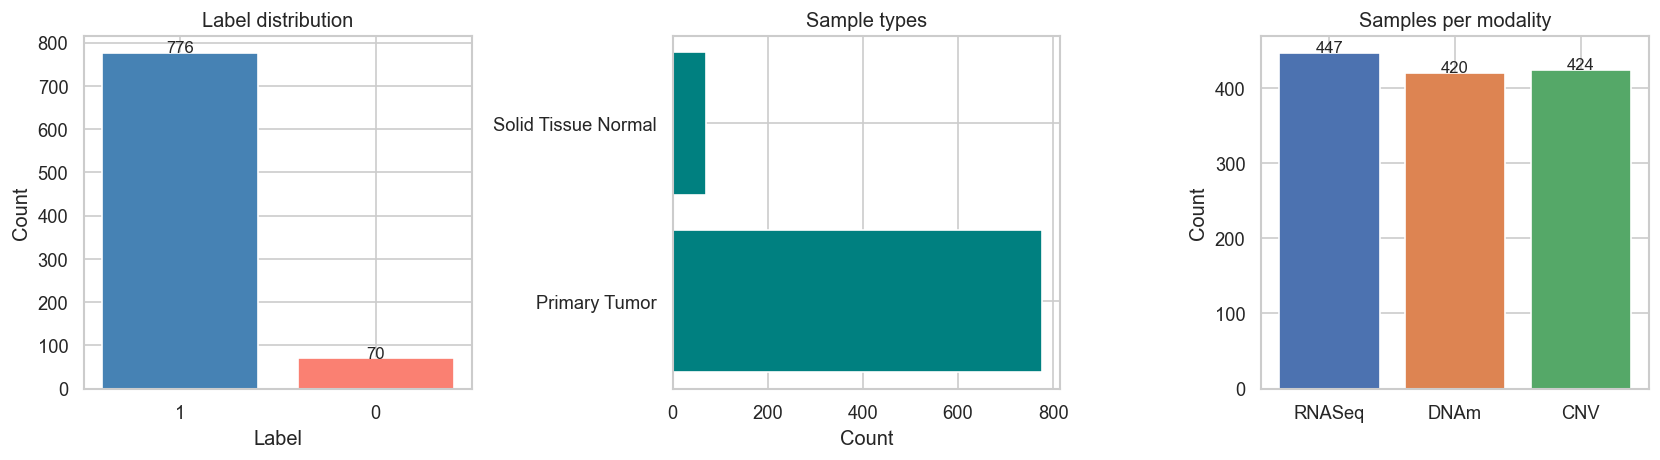

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Label distribution
label_counts = meta['label'].value_counts()
axes[0].bar(label_counts.index.astype(str), label_counts.values, color=['steelblue','salmon'])
axes[0].set_title('Label distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

# Sample type
st_counts = meta['sample_type'].value_counts()
axes[1].barh(st_counts.index, st_counts.values, color='teal')
axes[1].set_title('Sample types')
axes[1].set_xlabel('Count')

# Data availability per modality
avail = {
    'RNASeq': meta['has_RNASeq'].sum(),
    'DNAm':   meta['has_DNAm'].sum(),
    'CNV':    meta['has_CNV'].sum()
}
axes[2].bar(avail.keys(), avail.values(), color=['#4c72b0','#dd8452','#55a868'])
axes[2].set_title('Samples per modality')
axes[2].set_ylabel('Count')
for i, v in enumerate(avail.values()):
    axes[2].text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [49]:
# Samples with all three modalities
all3 = meta[meta['has_RNASeq'] & meta['has_DNAm'] & meta['has_CNV']]
print(f'Samples with all 3 modalities: {len(all3)}')
print('\nLabel breakdown (all-3):')
print(all3['label'].value_counts())

all2 = meta[meta['has_RNASeq'] & meta['has_CNV']]
print(f'Samples with 2 modalities: {len(all2)}')

Samples with all 3 modalities: 9

Label breakdown (all-3):
label
0    9
Name: count, dtype: int64
Samples with 2 modalities: 424


## 3. RNASeq — gene expression

### 3.1 Data processing

Common sample in meta table

In [63]:
rna_common = rnaseq.index.intersection(meta.index)
meta_rna = meta.loc[rna_common]
print('Number of aligned samples: ', len(meta_rna.index))
meta_rna.head()

Number of aligned samples:  447


,project,label,sample_type,has_RNASeq,has_DNAm,has_CNV
TCGA-69-7765,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-44-7669,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-91-7771,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-05-5715,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-64-1679,TCGA-LUAD,1,Primary Tumor,True,False,True


In [58]:
print('Shape:', rnaseq.shape)
print('\nValue range:')
print(rnaseq.stack().describe())

Shape: (447, 14434)

Value range:
count    6.451998e+06
mean     5.000000e-01
std      2.886952e-01
min      0.000000e+00
25%      2.499827e-01
50%      5.000000e-01
75%      7.500173e-01
max      1.000000e+00
dtype: float64


In [59]:
print('Missing values:', rnaseq.isnull().sum().sum())

Missing values: 0


### 3.2 Data distribution

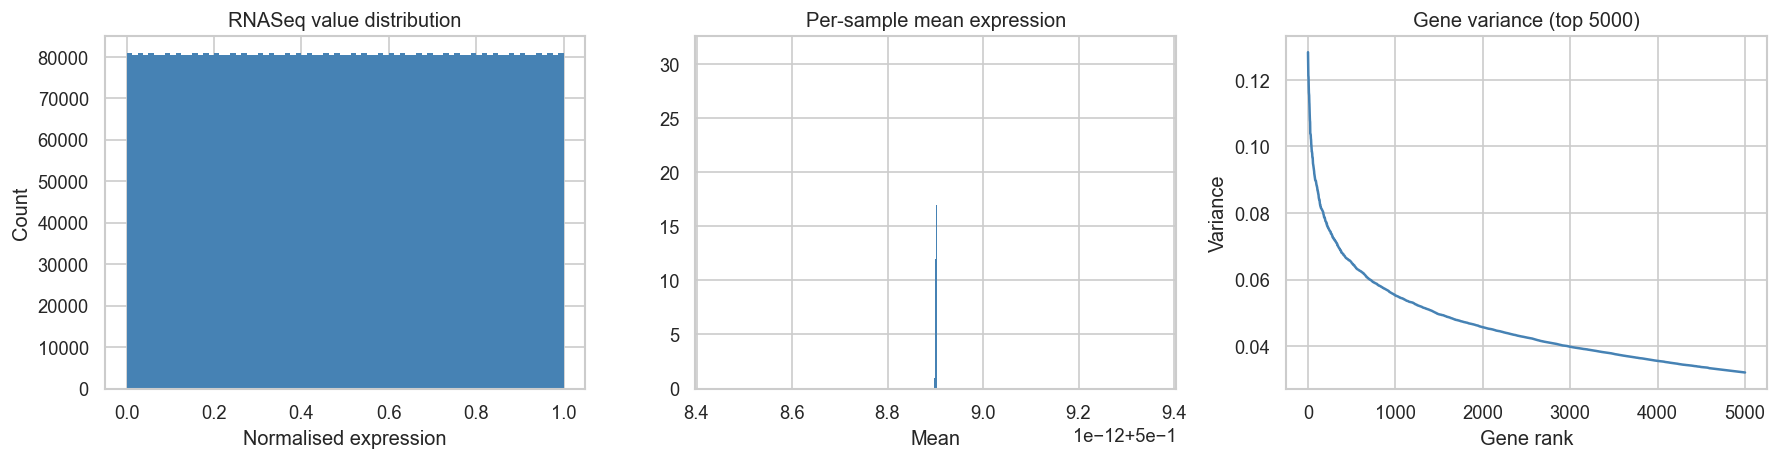

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of all values
flat_rna = rnaseq.values.ravel()
axes[0].hist(flat_rna, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('RNASeq value distribution')
axes[0].set_xlabel('Normalised expression')
axes[0].set_ylabel('Count')

# Per-sample mean expression
sample_means = rnaseq.mean(axis=1)
axes[1].hist(sample_means, bins=40, color='steelblue', edgecolor='none')
axes[1].set_title('Per-sample mean expression')
axes[1].set_xlabel('Mean')

# Gene variance distribution (top 1000)
gene_var = rnaseq.var(axis=0).sort_values(ascending=False)
axes[2].plot(range(len(gene_var[:5000])), gene_var[:5000].values, color='steelblue')
axes[2].set_title('Gene variance (top 5000)')
axes[2].set_xlabel('Gene rank')
axes[2].set_ylabel('Variance')

plt.tight_layout()
plt.show()

In [61]:
# Top 10 most variable genes
print('Top 10 most variable genes:')
print(gene_var.head(10).to_string())

Top 10 most variable genes:
SCGB1A1     0.128297
PPP1R14D    0.126092
FGB         0.123887
LGSN        0.121628
GLB1L3      0.121148
VIL1        0.121088
GPX2        0.120733
SPINK1      0.118337
GPR87       0.118292
HOXC10      0.116791


### 3.3 PCA

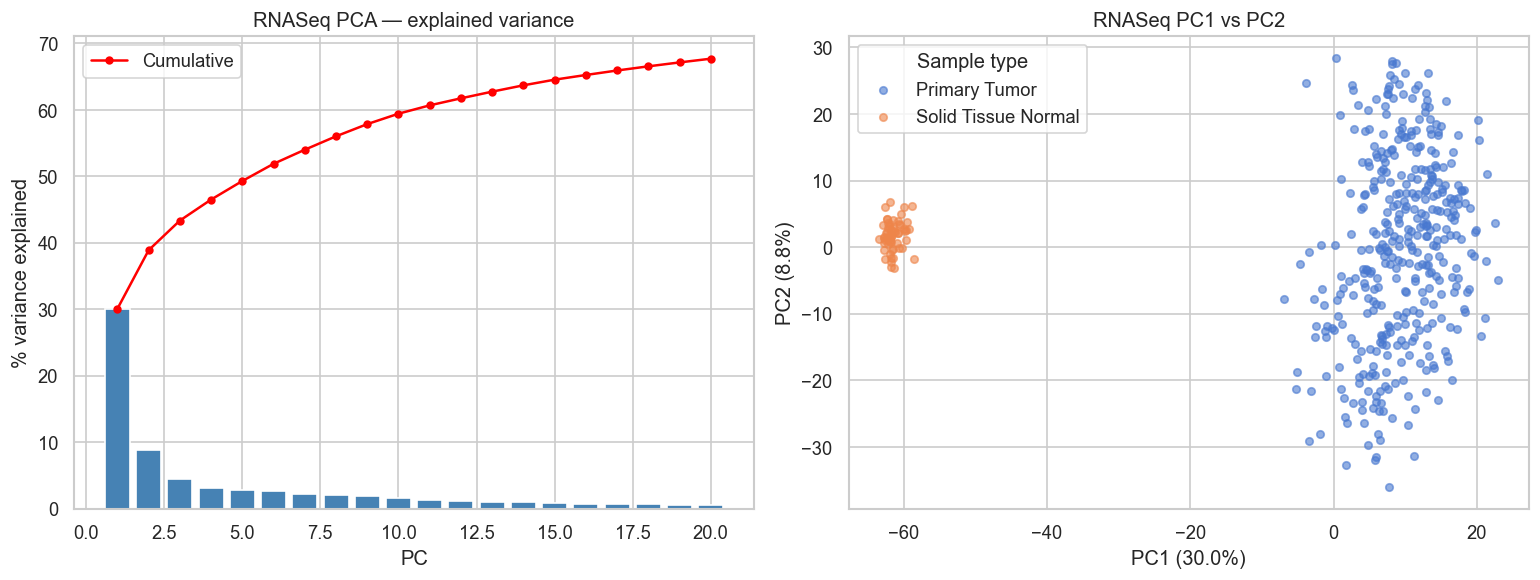

In [136]:
# PCA on top 2000 most variable genes
top_genes = gene_var.head(2000).index
rna_sub   = rnaseq[top_genes]

scaler = StandardScaler()
rna_scaled = scaler.fit_transform(rna_sub)

pca_rna = PCA(n_components=20, random_state=42)
rna_pcs = pca_rna.fit_transform(rna_scaled)

pca_df = pd.DataFrame(
    rna_pcs[:, :2],
    columns=["PC1", "PC2"],
    index=rnaseq.index
)
pca_df = pca_df.join(meta_rna)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, 21), pca_rna.explained_variance_ratio_ * 100, color='steelblue')
axes[0].plot(range(1, 21), np.cumsum(pca_rna.explained_variance_ratio_) * 100,
             color='red', marker='o', markersize=4, label='Cumulative')
axes[0].set_title('RNASeq PCA — explained variance')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('% variance explained')
axes[0].legend()

# PC1 vs PC2, coloured by sample label
for label in pca_df["sample_type"].unique():
    subset = pca_df[pca_df["sample_type"] == label]

    axes[1].scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        s=20,
        label=label
    )

axes[1].set_title("RNASeq PC1 vs PC2")
axes[1].set_xlabel(f'PC1 ({pca_rna.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_rna.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].legend(title="Sample type")

plt.tight_layout()
# plt.savefig("pca_rnaseq.pdf")
plt.show()

### 3.4 Differential expression analysis

In [87]:
import numpy as np
from scipy.stats import ttest_ind

group_t = meta_rna[meta["sample_type"] == "Primary Tumor"].index # tumor sample
group_n = meta_rna[meta["sample_type"] == "Solid Tissue Normal"].index # normal sample

X_T = rnaseq.loc[group_t]
X_N = rnaseq.loc[group_n]

results = []

# Differential test for each gene
for gene in rnaseq.columns:
    t_stat, p_raw = ttest_ind(X_T[gene], X_N[gene], equal_var=False)

    lfc = X_T[gene].mean() - X_N[gene].mean()
    
    results.append((gene, lfc, t_stat, p_raw))

de_results = pd.DataFrame(results, columns=["gene", "lfc", "t_stat", "pvalue"])


from statsmodels.stats.multitest import multipletests

# multiple test
de_results['padj'] = multipletests(de_results['pvalue'], method='fdr_bh')[1]
de_results = de_results.set_index('gene').sort_values('padj')

# check results
n_sig = (de_results['padj'] < 0.05).sum()
print(f'Significant DEGs (padj < 0.05): {n_sig:,} / {len(de_results):,} genes tested')
de_results.head(10)

Significant DEGs (padj < 0.05): 13,175 / 14,434 genes tested


,lfc,t_stat,pvalue,padj
gene,,,,
TRIM34,0.848316,133.161659,0.0,0.0
TAF1A,0.609598,121.513221,0.0,0.0
TRPC4AP,-0.647741,-143.262114,0.0,0.0
SLC7A6OS,0.621087,180.890740,0.0,0.0
MIF,0.926590,373.725081,0.0,0.0
RAB11A,-0.711886,-120.490314,0.0,0.0
CASC3,-0.693449,-155.425614,0.0,0.0
KCTD10,-0.619514,-147.714467,0.0,0.0
SAP18,-0.712503,-128.819785,0.0,0.0


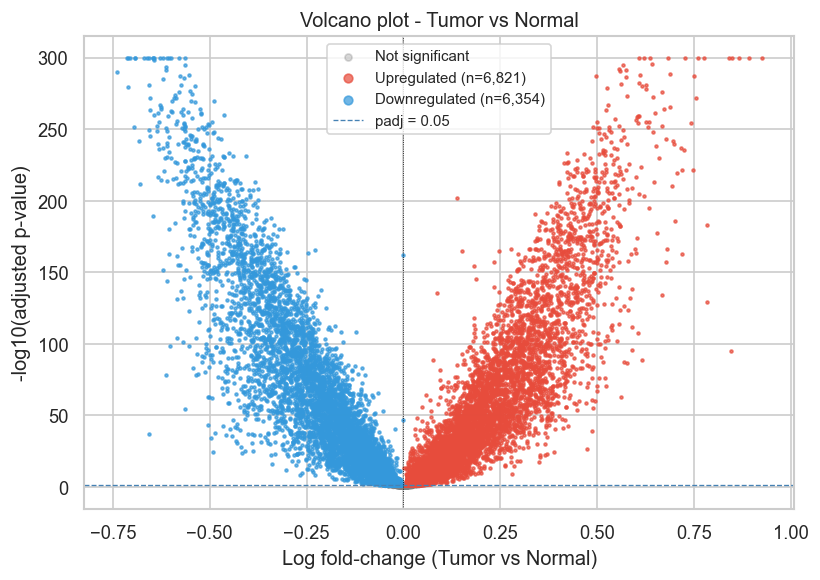

In [137]:
fig, ax = plt.subplots(figsize=(7, 5))

ns  = de_results['padj'] >= 0.05
sig = de_results['padj'] <  0.05

up = sig & (de_results['lfc'] > 0)
down = sig & (de_results['lfc'] < 0)

ax.scatter(de_results.loc[ns,  'lfc'], -np.log10(de_results.loc[ns,  'padj'].clip(1e-300)),
           s=2, alpha=0.3, color='grey', label='Not significant')

# Upregulated
ax.scatter(
    de_results.loc[up, 'lfc'],
    -np.log10(de_results.loc[up, 'padj'].clip(1e-300)),
    s=3, alpha=0.7, color='#E74C3C', label=f'Upregulated (n={up.sum():,})'
)

# Downregulated
ax.scatter(
    de_results.loc[down, 'lfc'],
    -np.log10(de_results.loc[down, 'padj'].clip(1e-300)),
    s=3, alpha=0.7, color='#3498DB', label=f'Downregulated (n={down.sum():,})'
)

ax.axhline(-np.log10(0.05), color='steelblue', lw=0.8, ls='--', label='padj = 0.05')
ax.axvline(0, color='black', lw=0.5, ls=':')

ax.set_xlabel('Log fold-change (Tumor vs Normal)')
ax.set_ylabel('-log10(adjusted p-value)')
ax.set_title("Volcano plot - Tumor vs Normal")
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
# plt.savefig("volcano_rnaseq.pdf")
plt.show()

### 3.5 Gene ontology analysis

<Axes: title={'center': 'GO enrichment'}, xlabel='Combined Score'>

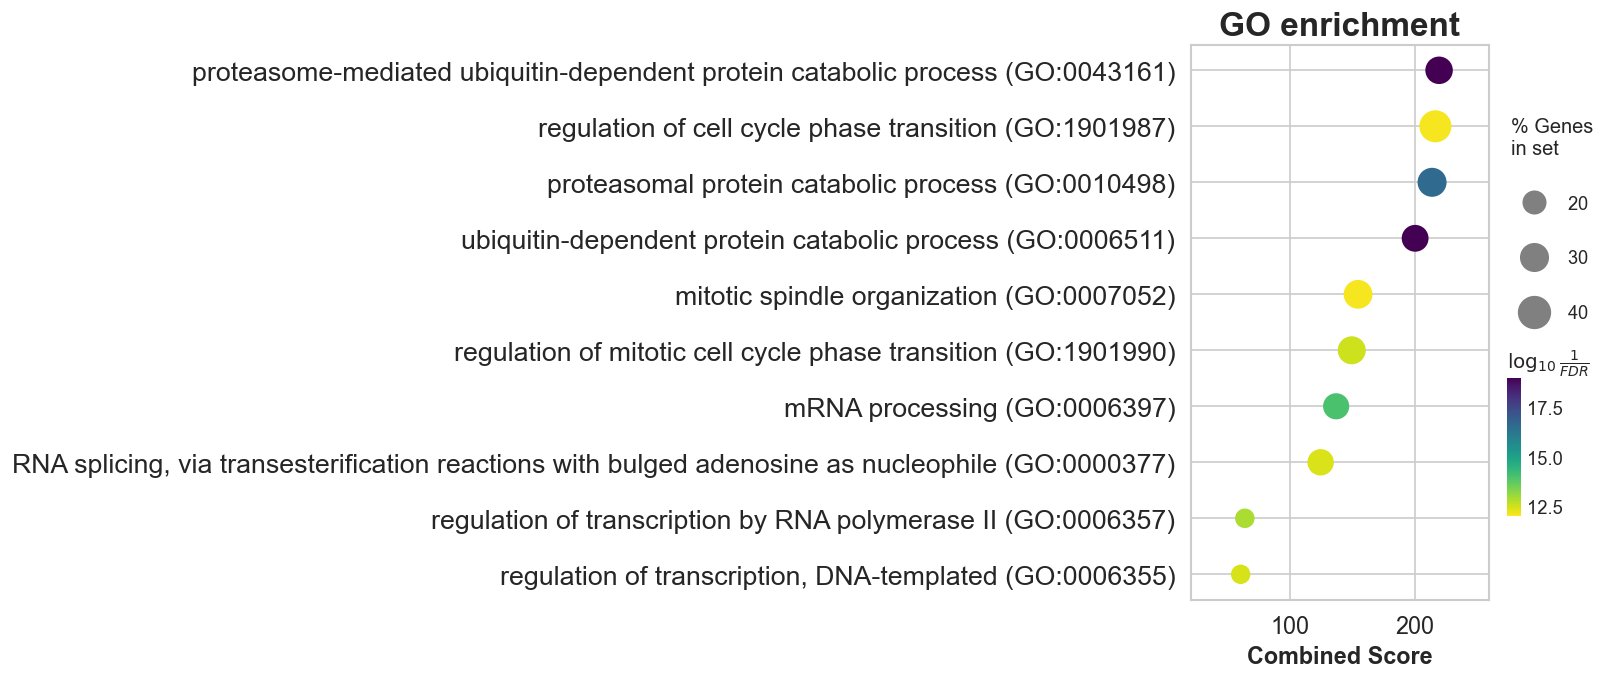

In [116]:
import gseapy as gp

top_degs = de_results.loc[de_results["padj"] < 0.05].head(2000).index.tolist()
up_genes = de_results.loc[(de_results["padj"] < 0.05) & (de_results["lfc"] > 0)].head(1000).index.tolist()
down_genes = de_results.loc[(de_results["padj"] < 0.05) & (de_results["lfc"] < 0)].head(1000).index.tolist()

# GO top all degs
enr = gp.enrichr(
      gene_list=top_degs,
      gene_sets=["GO_Biological_Process_2021"],
      outdir="go_results"
)

gp.dotplot(enr.results, title="GO enrichment")

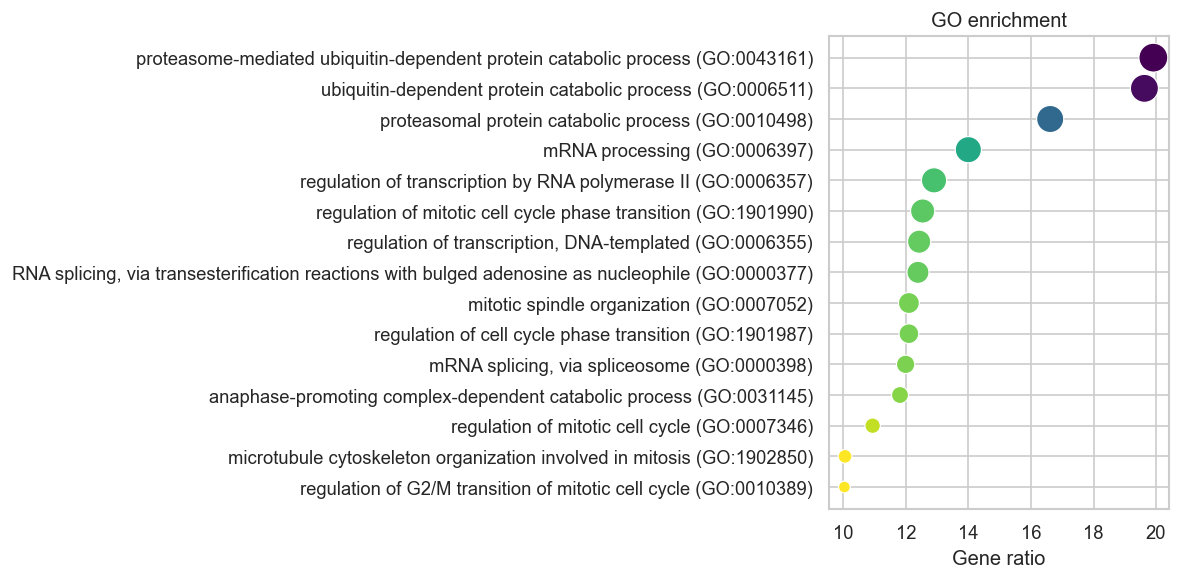

In [138]:
import seaborn as sns

df = enr.results[(enr.results["Adjusted P-value"] < 0.05)].sort_values("Adjusted P-value").head(15)
df["log_p"] = -np.log10(df["Adjusted P-value"])

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="log_p",
    y="Term",
    size="Overlap",
    hue="log_p",
    palette="viridis_r",
    sizes=(50, 300),
    legend=False
)
plt.xlabel("Gene ratio")
plt.ylabel("")
plt.title("GO enrichment")
plt.tight_layout()
# plt.savefig("GO_rnaseq.pdf")
plt.show()

In [ ]:
# GO up
gp.enrichr(
    gene_list=up_genes,
    gene_sets=["GO_Biological_Process_2021"],
    outdir="go_up"
)

# GO down
gp.enrichr(
    gene_list=up_genes,
    gene_sets=["GO_Biological_Process_2021"],
    outdir="go_up"
)

## 4. DNA Methylation

Common sample in meta table

In [65]:
dnam_common = dnam.index.intersection(meta.index)
meta_dnam = meta.loc[dnam_common]
print('Number of aligned samples: ', len(meta_dnam.index))
meta_dnam.head()

Number of aligned samples:  420


,project,label,sample_type,has_RNASeq,has_DNAm,has_CNV
TCGA-69-8255-01A,TCGA-LUAD,1,Primary Tumor,False,True,False
TCGA-73-A9RS-01A,TCGA-LUAD,1,Primary Tumor,False,True,False
TCGA-44-5644-01A,TCGA-LUAD,1,Primary Tumor,False,True,False
TCGA-MP-A4SV-01A,TCGA-LUAD,1,Primary Tumor,False,True,False
TCGA-55-8087-01A,TCGA-LUAD,1,Primary Tumor,False,True,False


In [66]:
print('Shape:', dnam.shape)
print('\nValue range (β-values expected in [0,1]):')
print(dnam.stack().describe())

Shape: (420, 384629)

Value range (β-values expected in [0,1]):
count    1.615442e+08
mean     4.982164e-01
std      3.634406e-01
min      0.000000e+00
25%      8.200000e-02
50%      5.420000e-01
75%      8.680000e-01
max      1.000000e+00
dtype: float64


In [67]:
missing_cpg = dnam.isnull().sum()
pct_missing = (missing_cpg > 0).sum() / dnam.shape[1] * 100
print(f'CpG sites with any missing value: {(missing_cpg>0).sum()} ({pct_missing:.1f}%)')
print(f'Total missing entries: {dnam.isnull().sum().sum()}')

CpG sites with any missing value: 0 (0.0%)
Total missing entries: 0


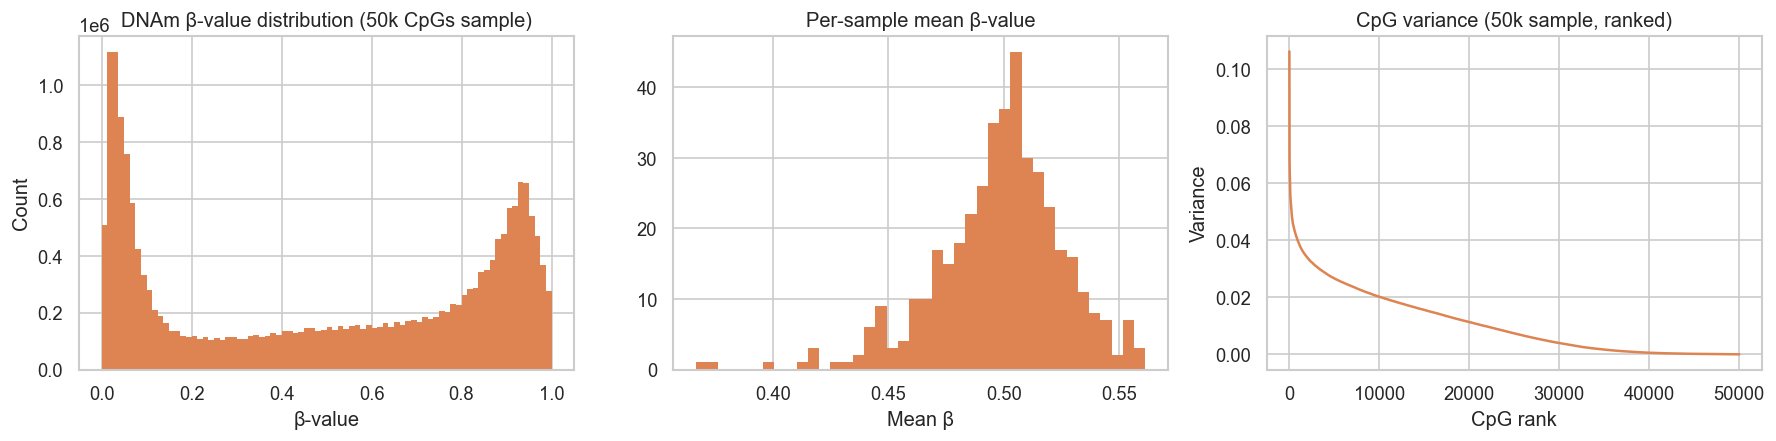

In [139]:
# Sample a subset for speed (384 k columns → plot subset)
np.random.seed(42)
sample_cpg = np.random.choice(dnam.columns, size=50000, replace=False)
dnam_sub = dnam[sample_cpg]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

flat_dnam = dnam_sub.values.ravel()
flat_dnam = flat_dnam[~np.isnan(flat_dnam)]
axes[0].hist(flat_dnam, bins=80, color='#dd8452', edgecolor='none')
axes[0].set_title('DNAm β-value distribution (50k CpGs sample)')
axes[0].set_xlabel('β-value')
axes[0].set_ylabel('Count')

sample_mean_m = dnam.mean(axis=1)
axes[1].hist(sample_mean_m, bins=40, color='#dd8452', edgecolor='none')
axes[1].set_title('Per-sample mean β-value')
axes[1].set_xlabel('Mean β')

cpg_var = dnam_sub.var(axis=0).sort_values(ascending=False)
axes[2].plot(range(len(cpg_var)), cpg_var.values, color='#dd8452')
axes[2].set_title('CpG variance (50k sample, ranked)')
axes[2].set_xlabel('CpG rank')
axes[2].set_ylabel('Variance')

plt.tight_layout()
# plt.savefig("distribution_dnam.pdf")
plt.show()

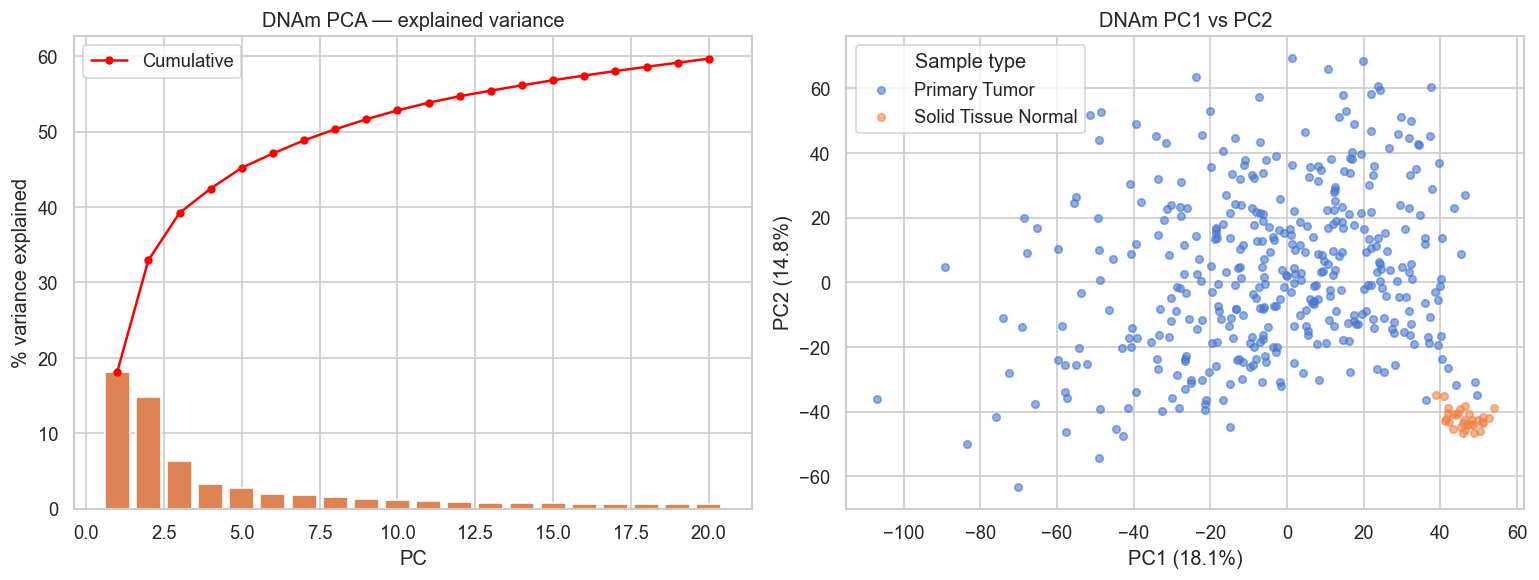

In [140]:
# PCA on top 5000 most variable CpGs (from 50k sample)
top_cpgs   = cpg_var.head(5000).index
dnam_pca_in = dnam[top_cpgs].dropna(axis=1)  # drop any remaining NaN columns

dnam_scaled = StandardScaler().fit_transform(dnam_pca_in)
pca_dnam = PCA(n_components=20, random_state=42)
dnam_pcs = pca_dnam.fit_transform(dnam_scaled)

pca_df = pd.DataFrame(
    dnam_pcs[:, :2],
    columns=["PC1", "PC2"],
    index=dnam.index
)
pca_df = pca_df.join(meta_dnam)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# screen plot
axes[0].bar(range(1, 21), pca_dnam.explained_variance_ratio_ * 100, color='#dd8452')
axes[0].plot(range(1, 21), np.cumsum(pca_dnam.explained_variance_ratio_) * 100,
             color='red', marker='o', markersize=4, label='Cumulative')
axes[0].set_title('DNAm PCA — explained variance')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('% variance explained')
axes[0].legend()

# PCA plot
for label in pca_df["sample_type"].unique():
    subset = pca_df[pca_df["sample_type"] == label]

    axes[1].scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        s=20,
        label=label
    )

axes[1].set_title("DNAm PC1 vs PC2")
axes[1].set_xlabel(f'PC1 ({pca_dnam.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_dnam.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].legend(title="Sample type")

plt.tight_layout()
# plt.savefig("pca_dnam.pdf")
plt.show()

## 5. Copy-Number Variation

Common sample in meta table

In [71]:
cnv_common = cnv.index.intersection(meta.index)
meta_cnv = meta.loc[cnv_common]
print('Number of aligned samples: ', len(meta_cnv.index))
meta_cnv.head()

Number of aligned samples:  424


,project,label,sample_type,has_RNASeq,has_DNAm,has_CNV
TCGA-69-7765,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-44-7669,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-91-7771,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-05-5715,TCGA-LUAD,1,Primary Tumor,True,False,True
TCGA-64-1679,TCGA-LUAD,1,Primary Tumor,True,False,True


In [72]:
print('Shape:', cnv.shape)
print('\nValue summary:')
print(cnv.stack().describe())

Shape: (424, 14434)

Value summary:
count    6.120016e+06
mean     5.161678e-01
std      9.705381e-02
min      0.000000e+00
25%      4.780000e-01
50%      5.010000e-01
75%      5.350000e-01
max      1.000000e+00
dtype: float64


In [73]:
print('Missing values:', cnv.isnull().sum().sum())

Missing values: 0


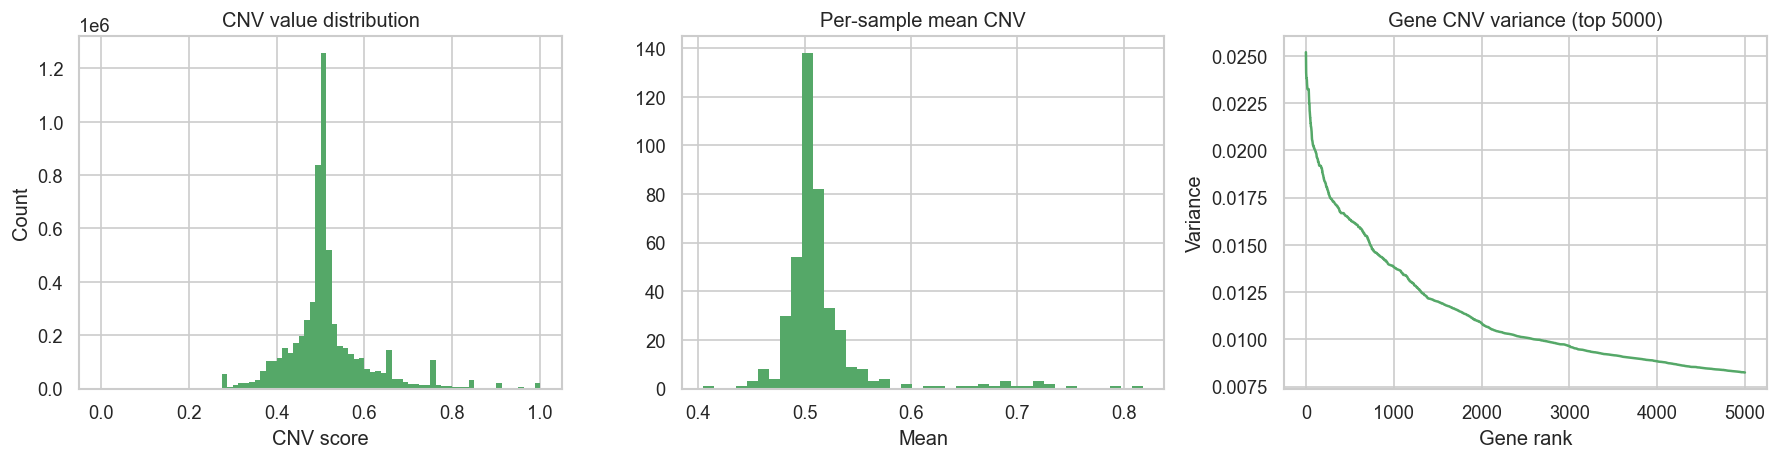

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

flat_cnv = cnv.values.ravel()
axes[0].hist(flat_cnv, bins=80, color='#55a868', edgecolor='none')
axes[0].set_title('CNV value distribution')
axes[0].set_xlabel('CNV score')
axes[0].set_ylabel('Count')

sample_mean_cnv = cnv.mean(axis=1)
axes[1].hist(sample_mean_cnv, bins=40, color='#55a868', edgecolor='none')
axes[1].set_title('Per-sample mean CNV')
axes[1].set_xlabel('Mean')

gene_var_cnv = cnv.var(axis=0).sort_values(ascending=False)
axes[2].plot(range(len(gene_var_cnv[:5000])), gene_var_cnv[:5000].values, color='#55a868')
axes[2].set_title('Gene CNV variance (top 5000)')
axes[2].set_xlabel('Gene rank')
axes[2].set_ylabel('Variance')

plt.tight_layout()
# plt.savefig("distribution_cnv.pdf")
plt.show()

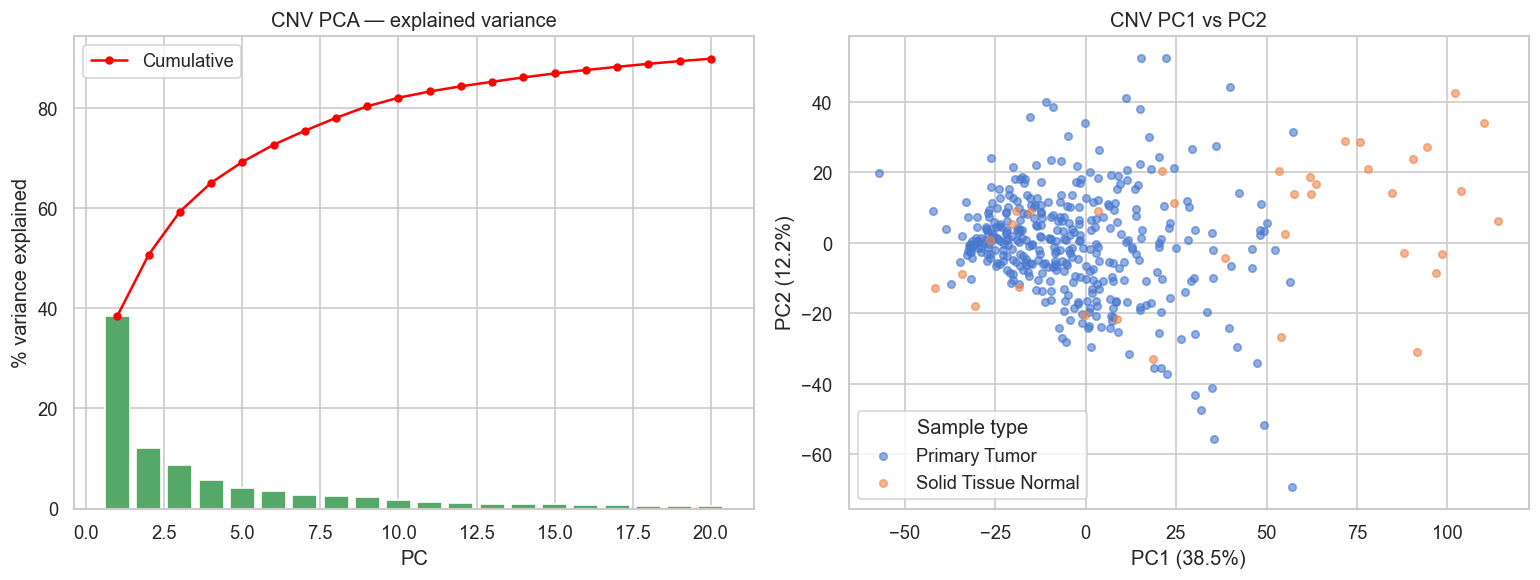

In [142]:
# PCA on top 2000 most variable CNV genes
top_cnv_genes = gene_var_cnv.head(2000).index
cnv_sub       = cnv[top_cnv_genes]

cnv_scaled = StandardScaler().fit_transform(cnv_sub)
pca_cnv = PCA(n_components=20, random_state=42)
cnv_pcs = pca_cnv.fit_transform(cnv_scaled)

pca_df = pd.DataFrame(
    cnv_pcs[:, :2],
    columns=["PC1", "PC2"],
    index=cnv.index
)
pca_df = pca_df.join(meta_cnv)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# screen plot
axes[0].bar(range(1, 21), pca_cnv.explained_variance_ratio_ * 100, color='#55a868')
axes[0].plot(range(1, 21), np.cumsum(pca_cnv.explained_variance_ratio_) * 100,
             color='red', marker='o', markersize=4, label='Cumulative')
axes[0].set_title('CNV PCA — explained variance')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('% variance explained')
axes[0].legend()

# PCA plot
for label in pca_df["sample_type"].unique():
    subset = pca_df[pca_df["sample_type"] == label]

    axes[1].scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        s=20,
        label=label
    )

axes[1].set_title("CNV PC1 vs PC2")
axes[1].set_xlabel(f'PC1 ({pca_cnv.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_cnv.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].legend(title="Sample type")

plt.tight_layout()
# plt.savefig("pca_cnv.pdf")
plt.show()

## 6. Cross-modality: sample overlap and PCA coloured by label

Harmonise sample IDs across modalities (RNASeq uses `.` separators, metadata uses `-`).

In [81]:
label_map = meta['label']
print(label_map)

patient_id
TCGA-69-7765        1
TCGA-44-7669        1
TCGA-91-7771        1
TCGA-05-5715        1
TCGA-64-1679        1
                   ..
TCGA-50-6594-11A    0
TCGA-50-6592-11A    0
TCGA-44-2656-11A    0
TCGA-50-6593-11A    0
TCGA-50-6591-11A    0
Name: label, Length: 846, dtype: int64


In [80]:
# Map patient_id → label from metadata
label_map = meta['label']

rna_labels  = rnaseq.index.map(label_map).values
dnam_labels = dnam.index.map(label_map).values
cnv_labels  = cnv.index.map(label_map).values

print('RNASeq label coverage:',  (~pd.isna(rna_labels)).sum(), '/', len(rna_labels))
print('DNAm label coverage:',    (~pd.isna(dnam_labels)).sum(), '/', len(dnam_labels))
print('CNV label coverage:',     (~pd.isna(cnv_labels)).sum(), '/', len(cnv_labels))

RNASeq label coverage: 447 / 447
DNAm label coverage: 420 / 420
CNV label coverage: 424 / 424


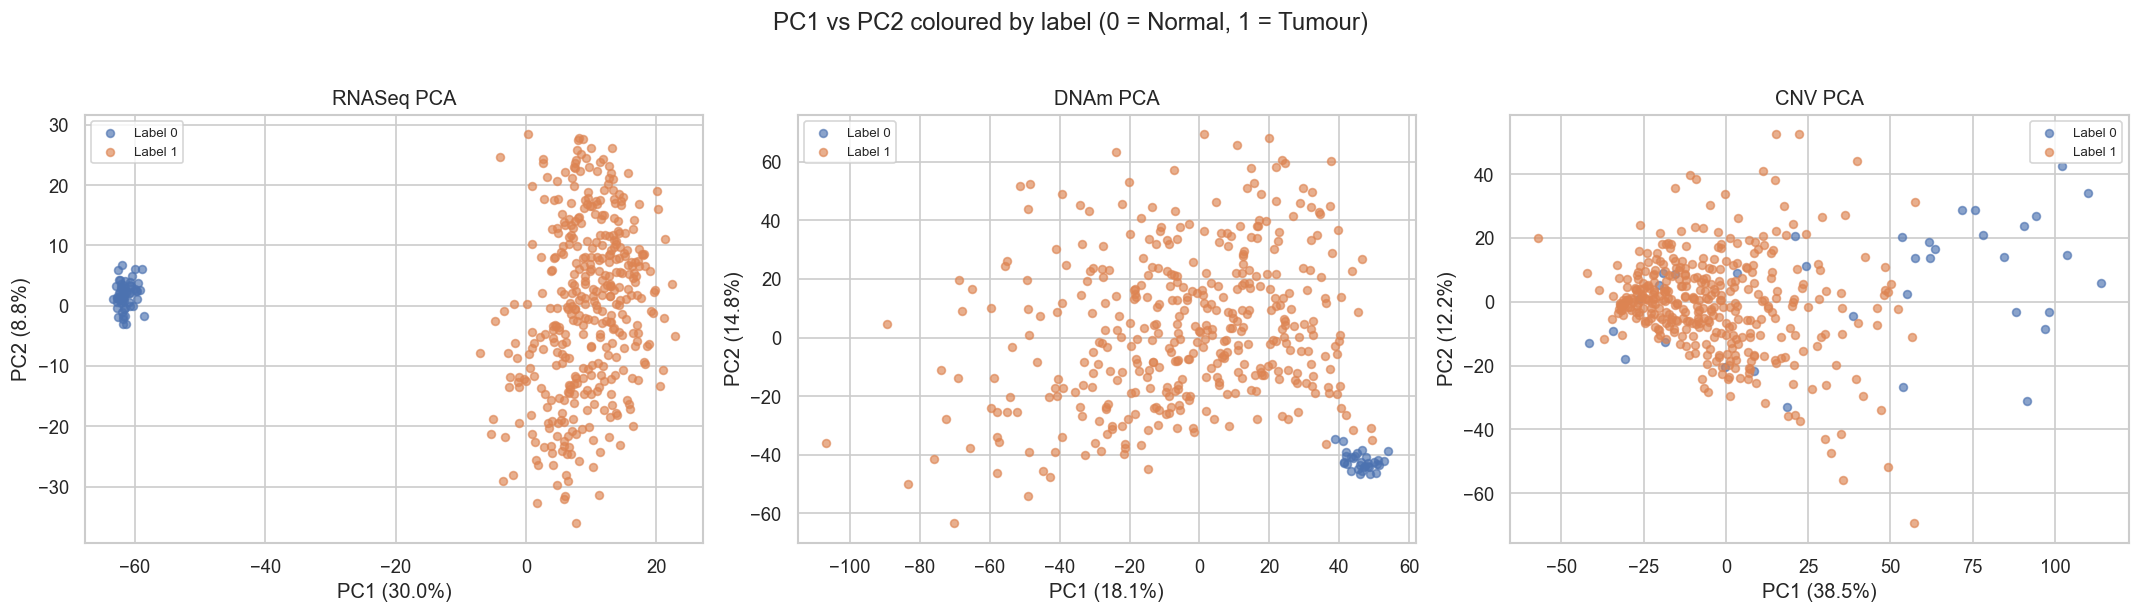

In [82]:
palette = {0: '#4c72b0', 1: '#dd8452'}

def pca_scatter(ax, pcs, labels, evr, title, cmap_dict):
    labels = np.array(labels, dtype=float)
    for val, col in cmap_dict.items():
        mask = labels == val
        ax.scatter(pcs[mask, 0], pcs[mask, 1],
                   alpha=0.65, s=22, c=col, label=f'Label {int(val)}')
    # plot unknowns
    unk = np.isnan(labels)
    if unk.any():
        ax.scatter(pcs[unk, 0], pcs[unk, 1], alpha=0.3, s=18, c='grey', label='Unknown')
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pca_scatter(axes[0], rna_pcs,  rna_labels,  pca_rna.explained_variance_ratio_,  'RNASeq PCA',  palette)
pca_scatter(axes[1], dnam_pcs, dnam_labels, pca_dnam.explained_variance_ratio_, 'DNAm PCA',    palette)
pca_scatter(axes[2], cnv_pcs,  cnv_labels,  pca_cnv.explained_variance_ratio_,  'CNV PCA',     palette)
plt.suptitle('PC1 vs PC2 coloured by label (0 = Normal, 1 = Tumour)', y=1.02)
plt.tight_layout()
plt.show()

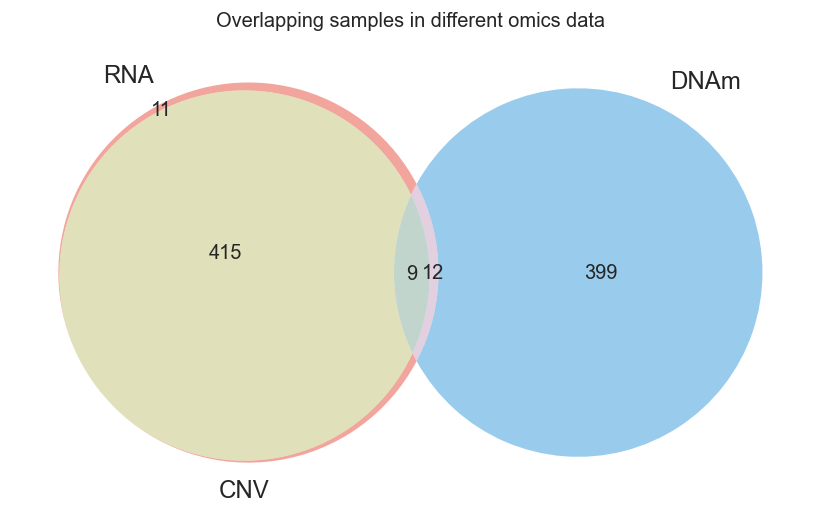

In [145]:
import matplotlib_venn as mvenn
subtype_colors = {'RNA': '#E74C3C', 'DNAm': '#3498DB', 'CNV': '#2ECC71'}

fig, ax = plt.subplots(figsize=(7, 6))
mvenn.venn3(
    subsets    = (set(rnaseq.index),
                  set(dnam.index),
                  set(cnv.index)),
    set_labels = ('RNA', 'DNAm', 'CNV'),
    set_colors = (subtype_colors['RNA'],
                  subtype_colors['DNAm'],
                  subtype_colors['CNV']),
    alpha      = 0.5,
    ax         = ax
)
ax.set_title('Overlapping samples in different omics data', fontsize=12)
plt.tight_layout()
# plt.savefig("venn_plot.pdf")
plt.show()

## 7. Top variable features — cross-modality correlation heatmap

Select the top 30 most variable genes from RNASeq and CNV (same gene space) and check their correlation.

In [149]:
# Common genes between RNASeq and CNV
common_genes = list(set(rnaseq.columns) & set(cnv.columns))
print(f'Genes in common between RNASeq and CNV: {len(common_genes)}')

shared_samples = list(set(rnaseq.index) & set(cnv.index))
print(f'Shared samples (patient IDs): {len(shared_samples)}')

rna_shared = rnaseq.loc[shared_samples, common_genes]
cnv_shared = cnv.loc[shared_samples, common_genes]

Genes in common between RNASeq and CNV: 14434
Shared samples (patient IDs): 424


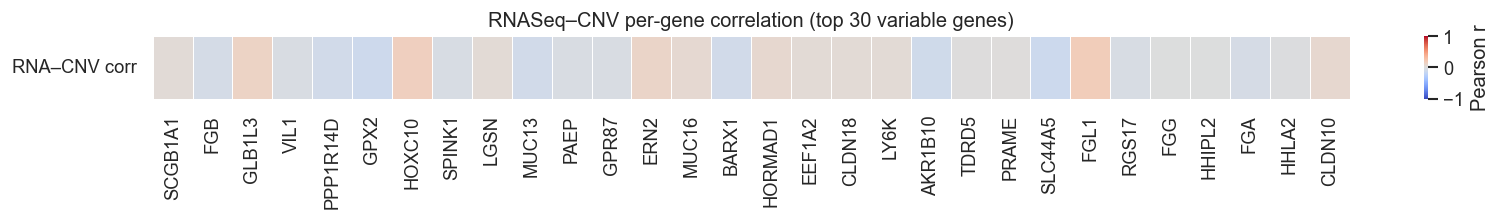

In [150]:
# Top 30 most variable genes in RNASeq (from the shared set)
top30 = rna_shared.var(axis=0).sort_values(ascending=False).head(30).index

# Correlation between RNASeq and CNV across samples for each gene
rna_cnv_corr = pd.DataFrame({
    gene: rna_shared[gene].corr(cnv_shared[gene]) for gene in top30
}, index=['RNA–CNV corr'])

fig, ax = plt.subplots(figsize=(14, 2))
sns.heatmap(rna_cnv_corr, ax=ax, cmap='coolwarm', center=0,
            linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('RNASeq–CNV per-gene correlation (top 30 variable genes)')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

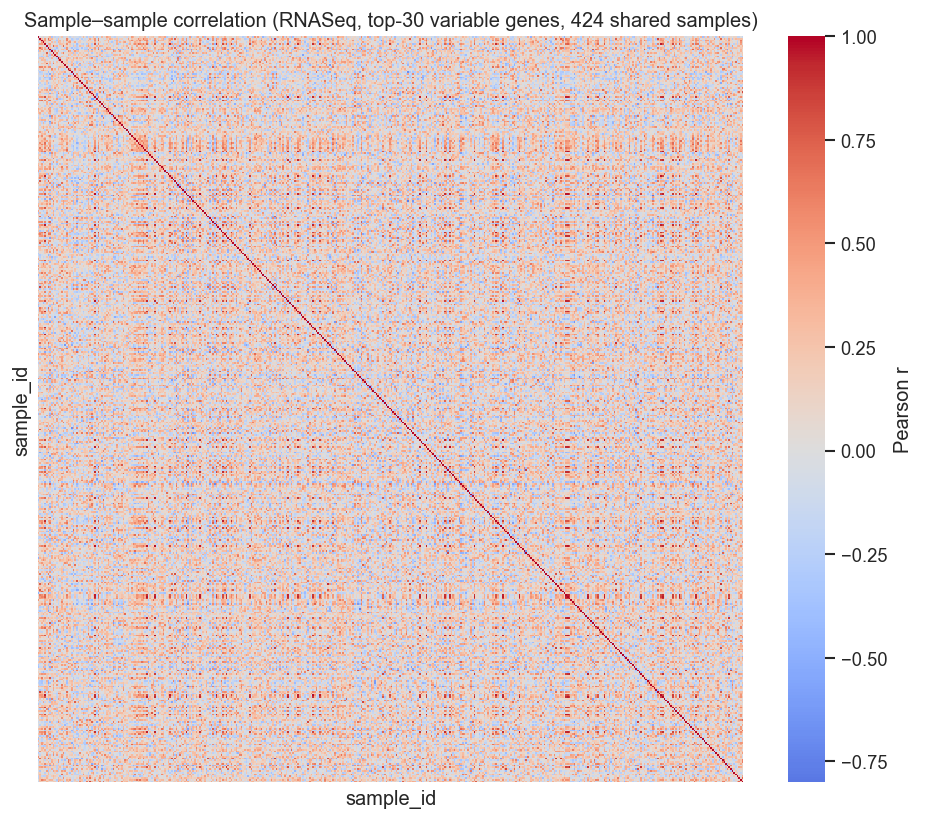

In [151]:
# Pairwise sample correlation within RNASeq (top 30 genes) as a heatmap
sample_corr_rna = rna_shared[top30].T.corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(sample_corr_rna, ax=ax, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Pearson r'})
ax.set_title(f'Sample–sample correlation (RNASeq, top-30 variable genes, {len(shared_samples)} shared samples)')
plt.tight_layout()
plt.show()

## 8. Summary table

In [152]:
summary = pd.DataFrame({
    'Modality': ['RNASeq', 'DNAm', 'CNV'],
    'Samples': [rnaseq.shape[0], dnam.shape[0], cnv.shape[0]],
    'Features': [rnaseq.shape[1], dnam.shape[1], cnv.shape[1]],
    'Missing (total)': [
        rnaseq.isnull().sum().sum(),
        dnam.isnull().sum().sum(),
        cnv.isnull().sum().sum()
    ],
    'Value min': [rnaseq.values.min(), dnam.values.min(), cnv.values.min()],
    'Value max': [rnaseq.values.max(), dnam.values.max(), cnv.values.max()],
    'PC1 var%': [
        pca_rna.explained_variance_ratio_[0]*100,
        pca_dnam.explained_variance_ratio_[0]*100,
        pca_cnv.explained_variance_ratio_[0]*100
    ]
}).set_index('Modality').round(3)

summary

,Samples,Features,Missing (total),Value min,Value max,PC1 var%
Modality,,,,,,
RNASeq,447,14434,0,0.0,1.0,30.050
DNAm,420,384629,0,0.0,1.0,18.143
CNV,424,14434,0,0.0,1.0,38.520
